# Ensemble Early Parkinson Detection Using Voice Biomarkers
**Course:** EECE5644 — Machine Learning and Pattern Recognition  
**Team:** Achintya Shah & Sheshang Ramesh  
**Date:** April 2026

---

This standalone notebook presents the complete pipeline — from exploratory analysis through
feature selection to a stacking ensemble classifier — for early Parkinson's disease detection
using the UCI Oxford Parkinson's Voice Dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import RFE
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    GroupKFold, StratifiedKFold, cross_val_score
)
from sklearn.metrics import (
    balanced_accuracy_score, accuracy_score, recall_score,
    precision_score, f1_score, matthews_corrcoef, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)
from sklearn.pipeline import Pipeline
from sklearn.base import clone

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_style('whitegrid')
sns.set_palette('colorblind')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('All imports loaded successfully.')

All imports loaded successfully.


---
## 1. Dataset Description & Loading

The **Oxford Parkinson's Disease Detection Dataset** (UCI Repository ID 174) contains 195
sustained vowel recordings from 31 individuals — 23 with Parkinson's disease and 8 healthy
controls. Each subject contributed approximately 6 recordings. The dataset includes 22
real-valued acoustic features spanning four groups:

| Feature Group | Count | Examples |
|---|---|---|
| Fundamental frequency | 3 | MDVP:Fo(Hz), MDVP:Fhi(Hz), MDVP:Flo(Hz) |
| Jitter (frequency perturbation) | 5 | MDVP:Jitter(%), MDVP:RAP, Jitter:DDP |
| Shimmer (amplitude perturbation) | 6 | MDVP:Shimmer, Shimmer:APQ3, Shimmer:DDA |
| Nonlinear dynamical / noise | 8 | RPDE, DFA, spread1, spread2, D2, PPE, NHR, HNR |

In [2]:
# Load dataset
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/parkinsons/parkinsons.data'
try:
    df = pd.read_csv(url)
except:
    # Fallback: load from local file if available
    df = pd.read_csv('parkinsons.data')

# Extract subject IDs from the 'name' column (e.g., 'phon_R01_S01_1' -> 'S01')
df['subject_id'] = df['name'].apply(lambda x: x.split('_')[2])

# Define feature columns (exclude 'name', 'status', 'subject_id')
FEATURE_COLS = [c for c in df.columns if c not in ['name', 'status', 'subject_id']]

X = df[FEATURE_COLS].values
y = df['status'].values
groups = df['subject_id']

print(f'Dataset shape: {df.shape}')
print(f'Features: {len(FEATURE_COLS)}')
print(f'Samples: {len(df)}')
print(f'Unique subjects: {groups.nunique()}')
print(f'\nFeature columns:\n{FEATURE_COLS}')

Dataset shape: (195, 25)
Features: 22
Samples: 195
Unique subjects: 32

Feature columns:
['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']


---
## 2. Exploratory Data Analysis

### 2.1 Class Distribution

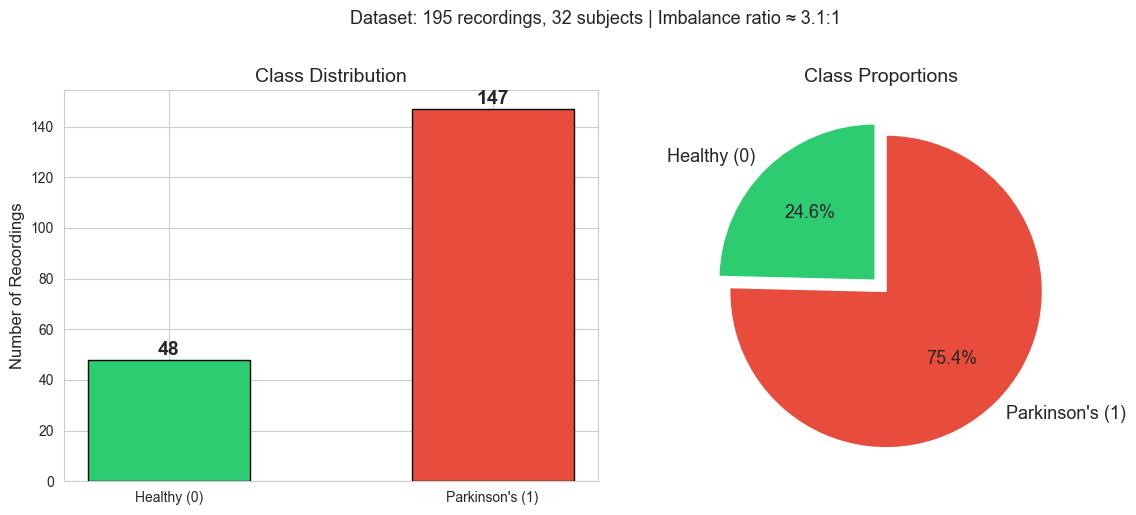

Healthy: 48 recordings (24.6%)
Parkinson's: 147 recordings (75.4%)
Imbalance ratio: 3.06:1


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
class_counts = df['status'].value_counts().sort_index()
labels = ['Healthy (0)', "Parkinson's (1)"]
colors = ['#2ecc71', '#e74c3c']

bars = axes[0].bar(labels, class_counts.values, color=colors,
                   edgecolor='black', width=0.5)
for bar, count in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(count), ha='center', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Recordings')
axes[0].set_title('Class Distribution')

# Pie chart
axes[1].pie(class_counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 13}, explode=(0.05, 0.05))
axes[1].set_title('Class Proportions')

plt.suptitle(
    f'Dataset: {class_counts.sum()} recordings, {groups.nunique()} subjects '
    f'| Imbalance ratio \u2248 {class_counts[1]/class_counts[0]:.1f}:1',
    fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f'Healthy: {class_counts[0]} recordings ({class_counts[0]/len(df)*100:.1f}%)')
print(f"Parkinson's: {class_counts[1]} recordings ({class_counts[1]/len(df)*100:.1f}%)")
print(f'Imbalance ratio: {class_counts[1]/class_counts[0]:.2f}:1')

### 2.2 Subject-Level Distribution

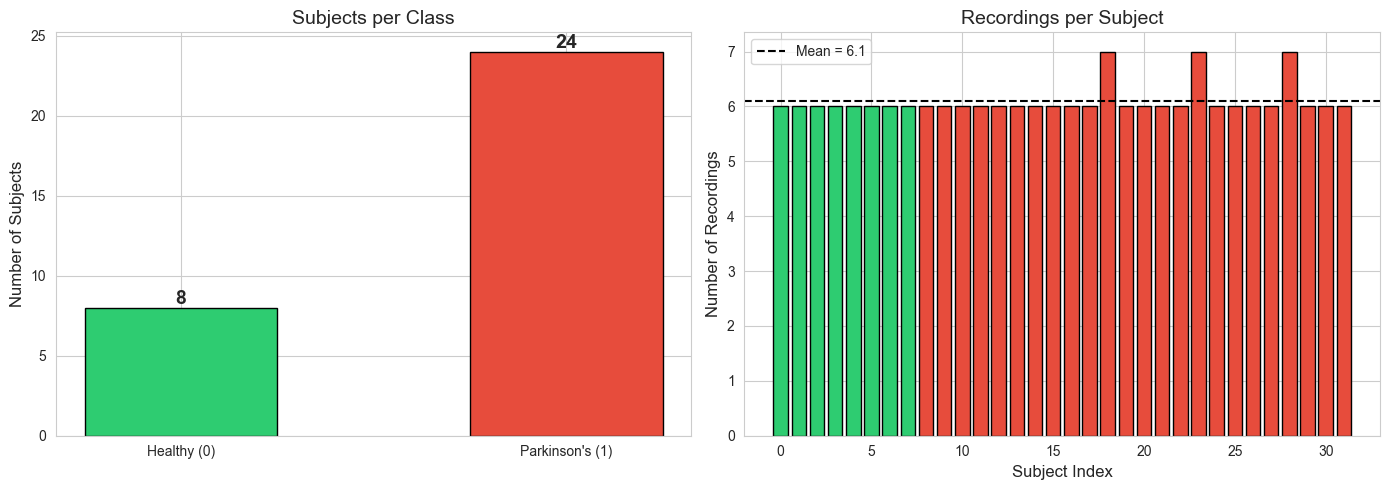

Healthy subjects: 8, PD subjects: 24
Recordings per subject: 6.1 ± 0.3


In [25]:
subject_info = df.groupby('subject_id').agg(
    status=('status', 'first'),
    n_recordings=('status', 'count')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2ecc71', '#e74c3c']

# Subjects per class
subj_counts = subject_info['status'].value_counts().sort_index()
subj_labels = ['Healthy (0)', "Parkinson's (1)"]
bars = axes[0].bar(subj_labels, subj_counts.values, color=colors,
                   edgecolor='black', width=0.5)
for bar, count in zip(bars, subj_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 str(count), ha='center', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Subjects')
axes[0].set_title('Subjects per Class')

# Recordings per subject
subject_info_sorted = subject_info.sort_values(['status', 'subject_id'])
bar_colors = [colors[s] for s in subject_info_sorted['status']]
axes[1].bar(range(len(subject_info_sorted)),
            subject_info_sorted['n_recordings'],
            color=bar_colors, edgecolor='black')
axes[1].set_xlabel('Subject Index')
axes[1].set_ylabel('Number of Recordings')
axes[1].set_title('Recordings per Subject')
axes[1].axhline(y=subject_info['n_recordings'].mean(), color='black',
                linestyle='--',
                label=f"Mean = {subject_info['n_recordings'].mean():.1f}")
axes[1].legend()
plt.legend()
plt.tight_layout()
plt.show()

print(f'Healthy subjects: {subj_counts[0]}, PD subjects: {subj_counts[1]}')
print(f"Recordings per subject: {subject_info['n_recordings'].mean():.1f} "
      f"\u00b1 {subject_info['n_recordings'].std():.1f}")

### 2.3 Descriptive Statistics

In [5]:
desc = df[FEATURE_COLS].describe().T
desc['range'] = desc['max'] - desc['min']
desc['cv'] = (desc['std'] / desc['mean']).abs()  # Coefficient of variation
print('Descriptive Statistics for All 22 Features:\n')
desc[['mean', 'std', 'min', '25%', '50%', '75%', 'max', 'range', 'cv']].round(4)

Descriptive Statistics for All 22 Features:



,mean,std,min,25%,50%,75%,max,range,cv
MDVP:Fo(Hz),154.2286,41.3901,88.3330,117.5720,148.7900,182.7690,260.1050,171.7720,0.2684
MDVP:Fhi(Hz),197.1049,91.4915,102.1450,134.8625,175.8290,224.2055,592.0300,489.8850,0.4642
MDVP:Flo(Hz),116.3246,43.5214,65.4760,84.2910,104.3150,140.0185,239.1700,173.6940,0.3741
MDVP:Jitter(%),0.0062,0.0048,0.0017,0.0035,0.0049,0.0074,0.0332,0.0315,0.7794
MDVP:Jitter(Abs),0.0000,0.0000,0.0000,0.0000,0.0000,0.0001,0.0003,0.0003,0.7921
MDVP:RAP,0.0033,0.0030,0.0007,0.0017,0.0025,0.0038,0.0214,0.0208,0.8976
MDVP:PPQ,0.0034,0.0028,0.0009,0.0019,0.0027,0.0040,0.0196,0.0187,0.8005
Jitter:DDP,0.0099,0.0089,0.0020,0.0050,0.0075,0.0115,0.0643,0.0623,0.8975
MDVP:Shimmer,0.0297,0.0189,0.0095,0.0165,0.0230,0.0379,0.1191,0.1095,0.6347
MDVP:Shimmer(dB),0.2823,0.1949,0.0850,0.1485,0.2210,0.3500,1.3020,1.2170,0.6904


### 2.4 Feature Distributions by Class

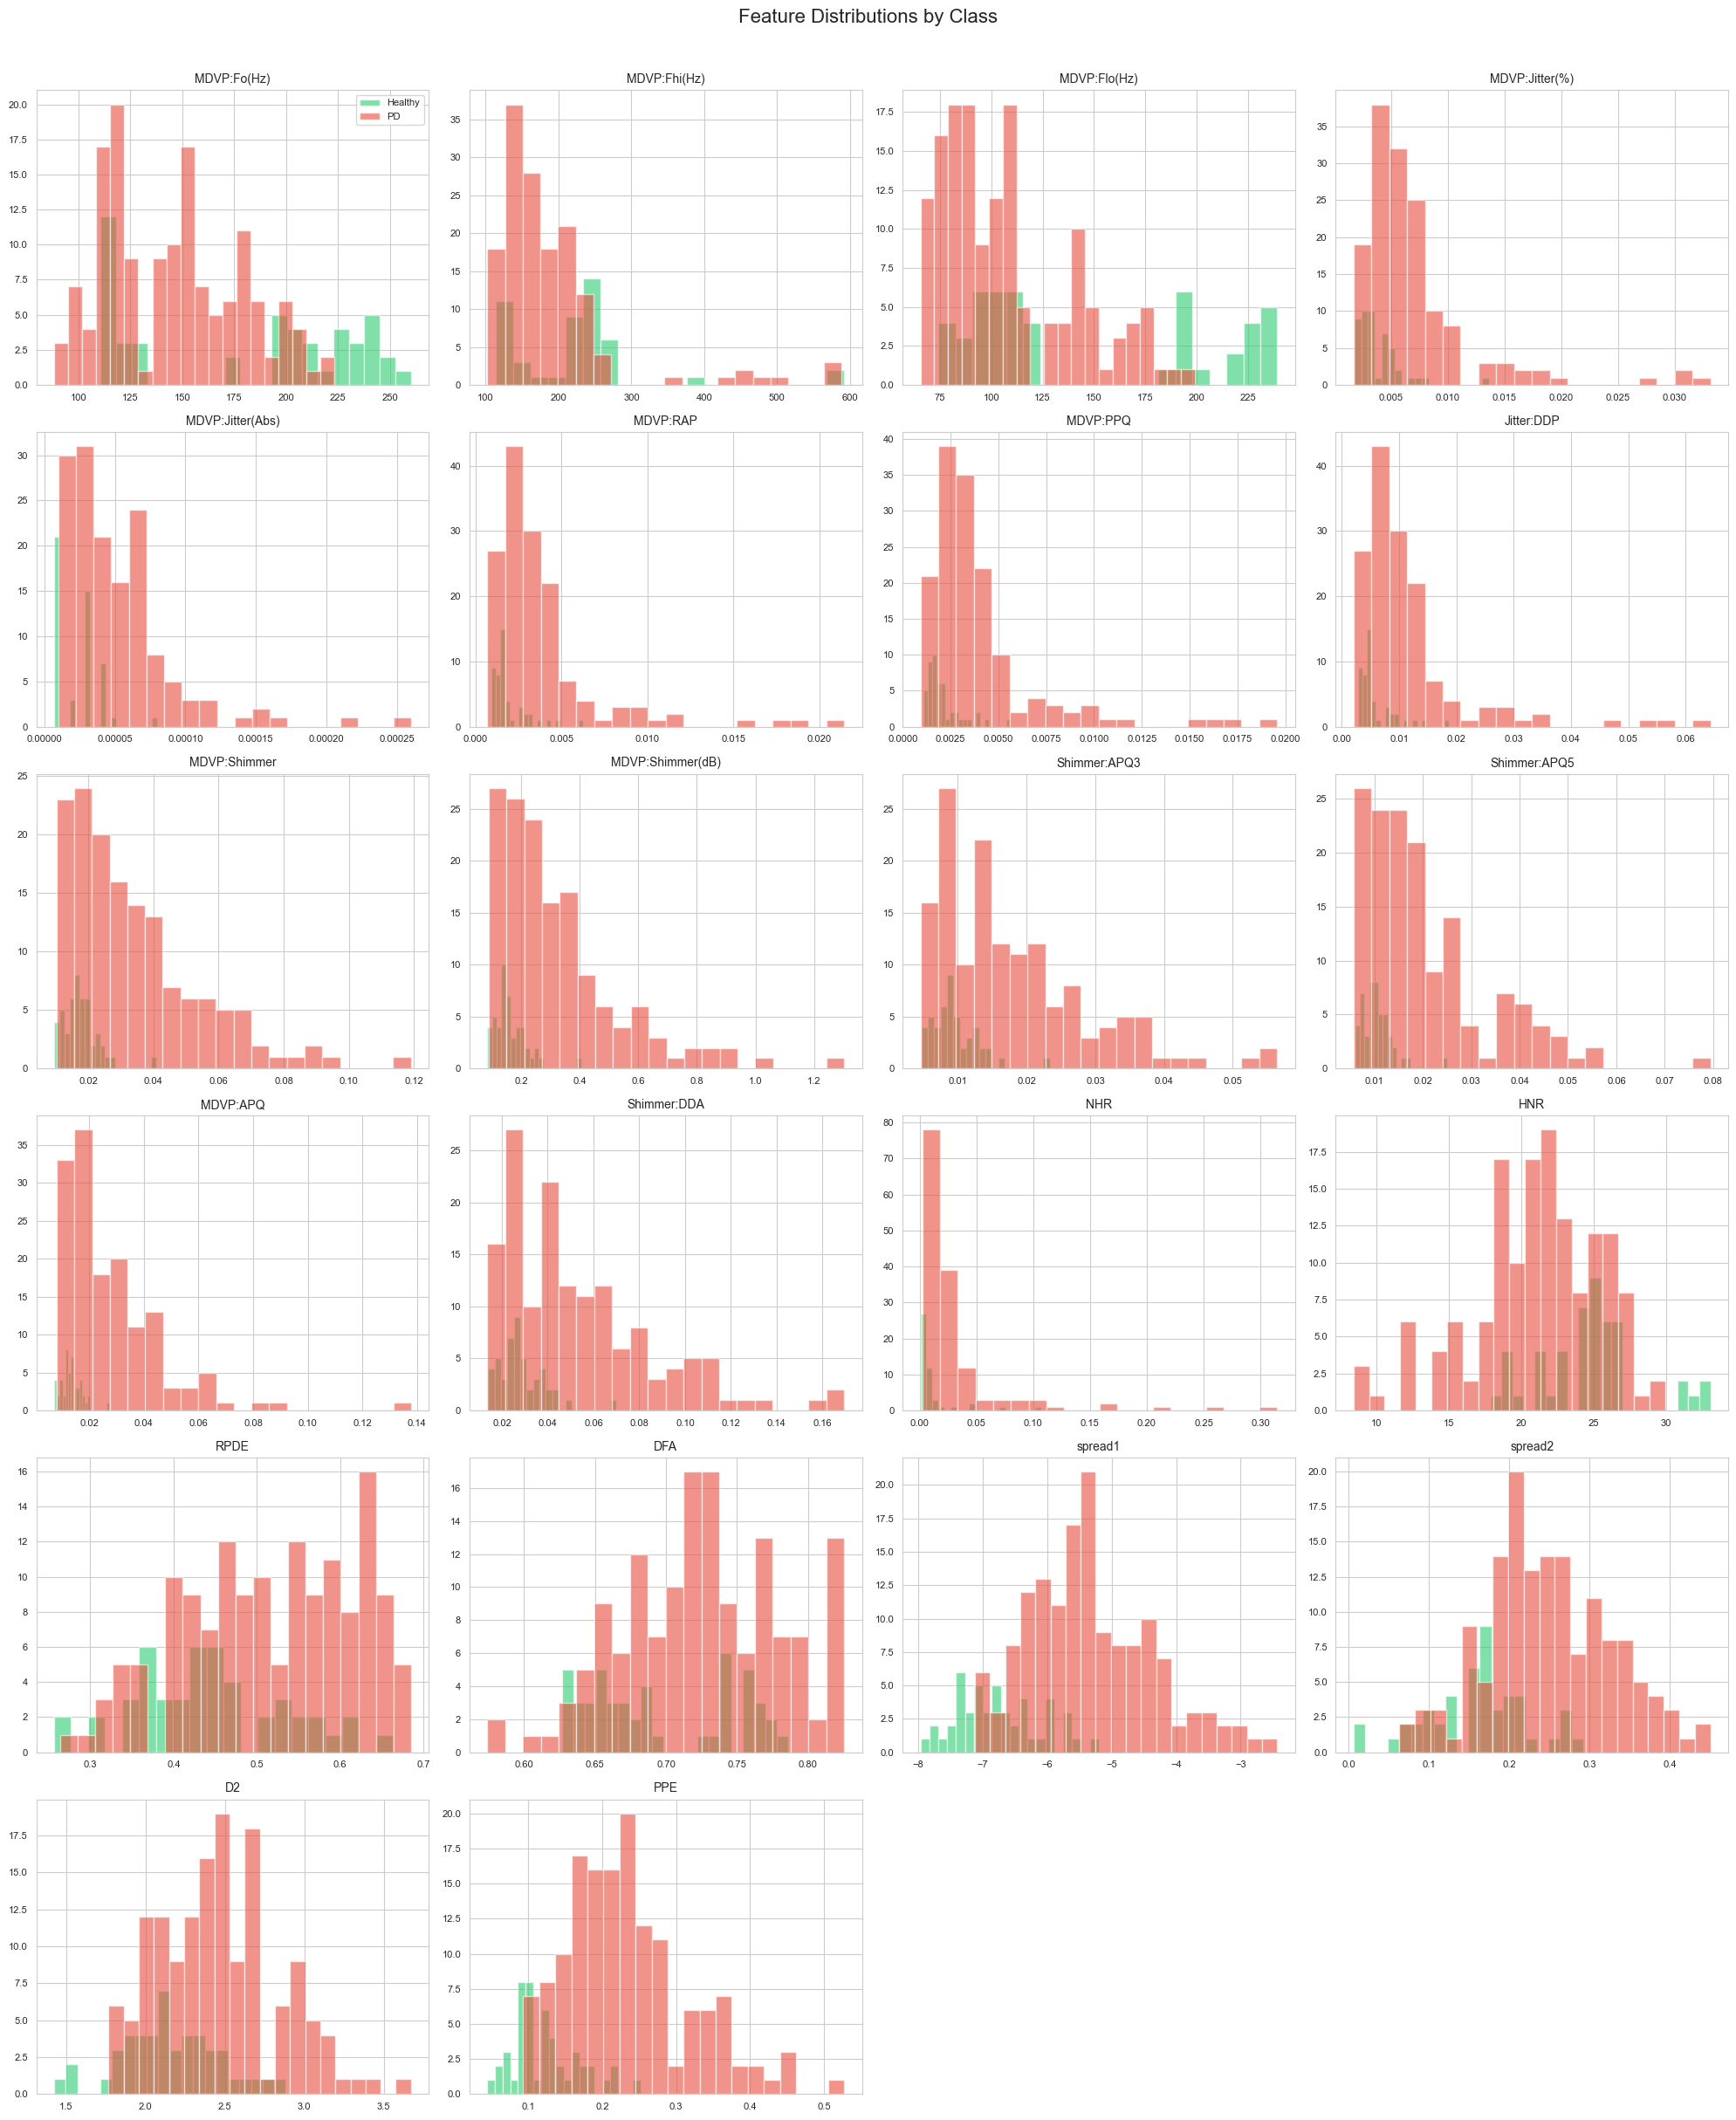

In [6]:
fig, axes = plt.subplots(6, 4, figsize=(20, 24))
axes_flat = axes.flatten()

for i, col in enumerate(FEATURE_COLS):
    ax = axes_flat[i]
    for status, color, label in [(0, '#2ecc71', 'Healthy'), (1, '#e74c3c', 'PD')]:
        data = df[df['status'] == status][col]
        ax.hist(data, bins=20, alpha=0.6, color=color, label=label,
                edgecolor='white')
    ax.set_title(col, fontsize=10)
    ax.tick_params(labelsize=8)
    if i == 0:
        ax.legend(fontsize=8)

# Hide unused subplots
for j in range(len(FEATURE_COLS), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('Feature Distributions by Class', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

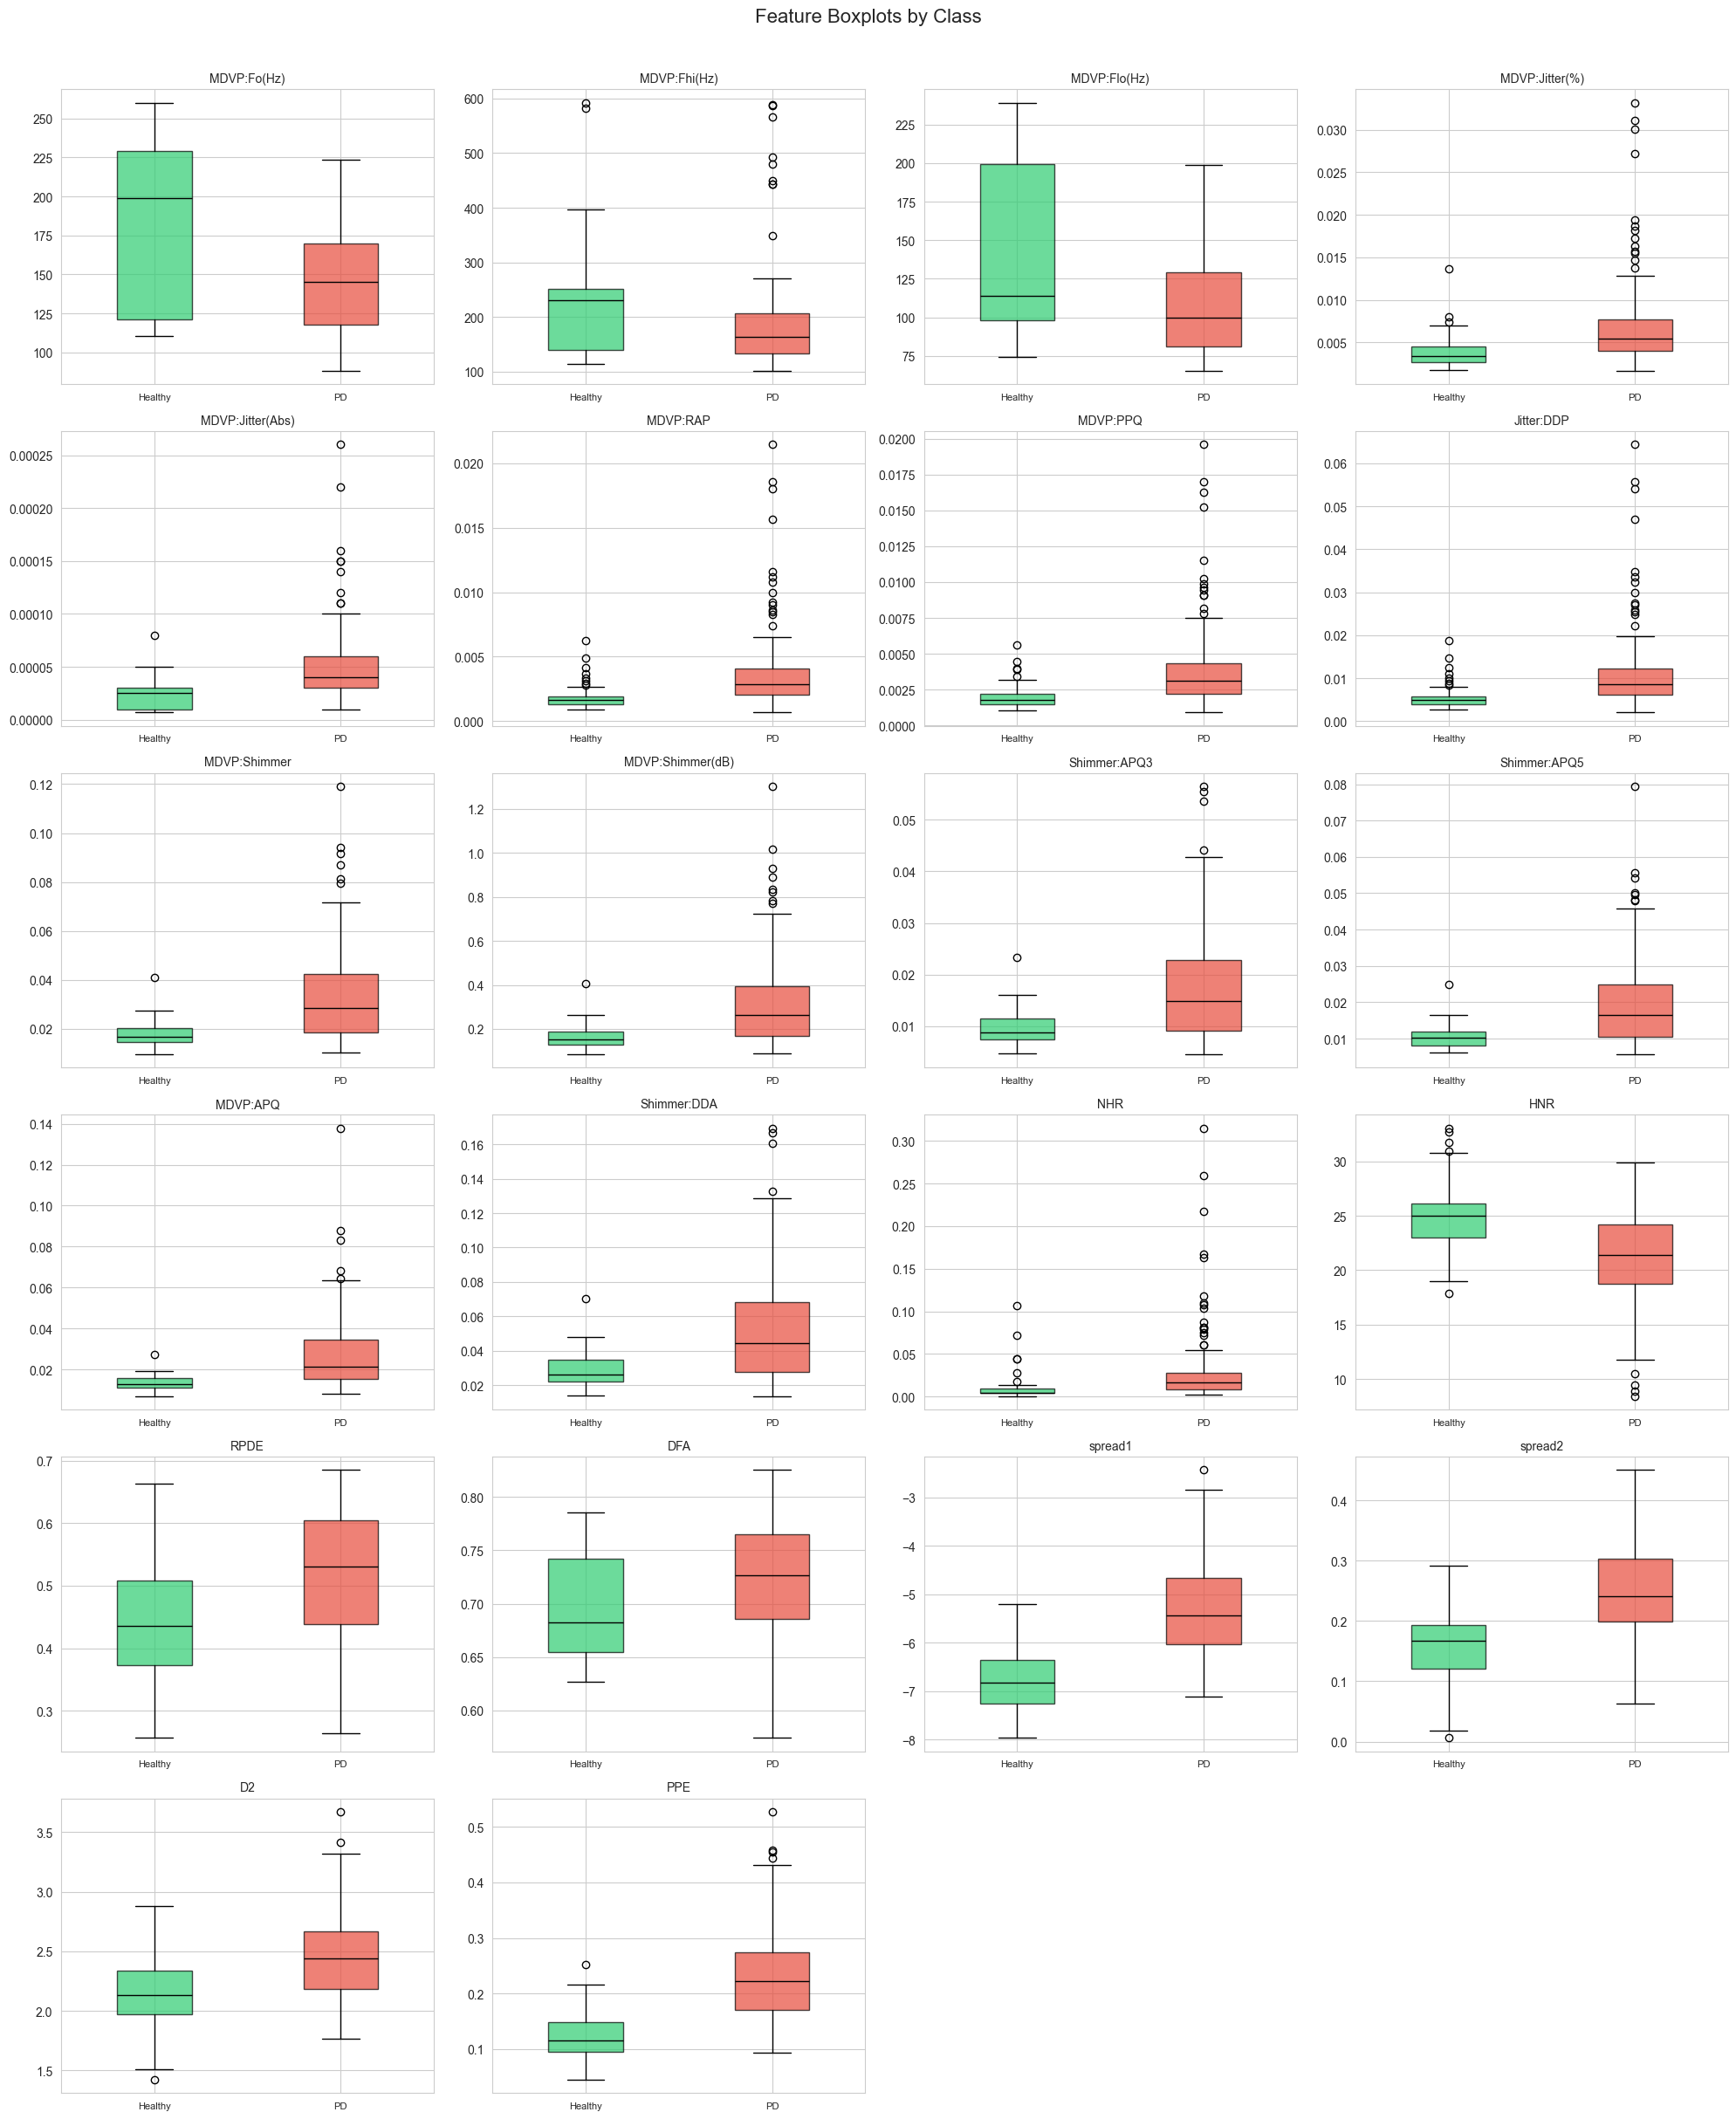

In [7]:
fig, axes = plt.subplots(6, 4, figsize=(20, 24))
axes_flat = axes.flatten()

for i, col in enumerate(FEATURE_COLS):
    ax = axes_flat[i]
    healthy = df[df['status'] == 0][col]
    pd_data = df[df['status'] == 1][col]
    bp = ax.boxplot([healthy, pd_data], positions=[0, 1], widths=0.4,
                    patch_artist=True,
                    medianprops=dict(color='black'))
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor('#e74c3c')
    bp['boxes'][1].set_alpha(0.7)
    ax.set_title(col, fontsize=10)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Healthy', 'PD'], fontsize=8)

for j in range(len(FEATURE_COLS), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('Feature Boxplots by Class', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

### 2.5 Feature Correlation

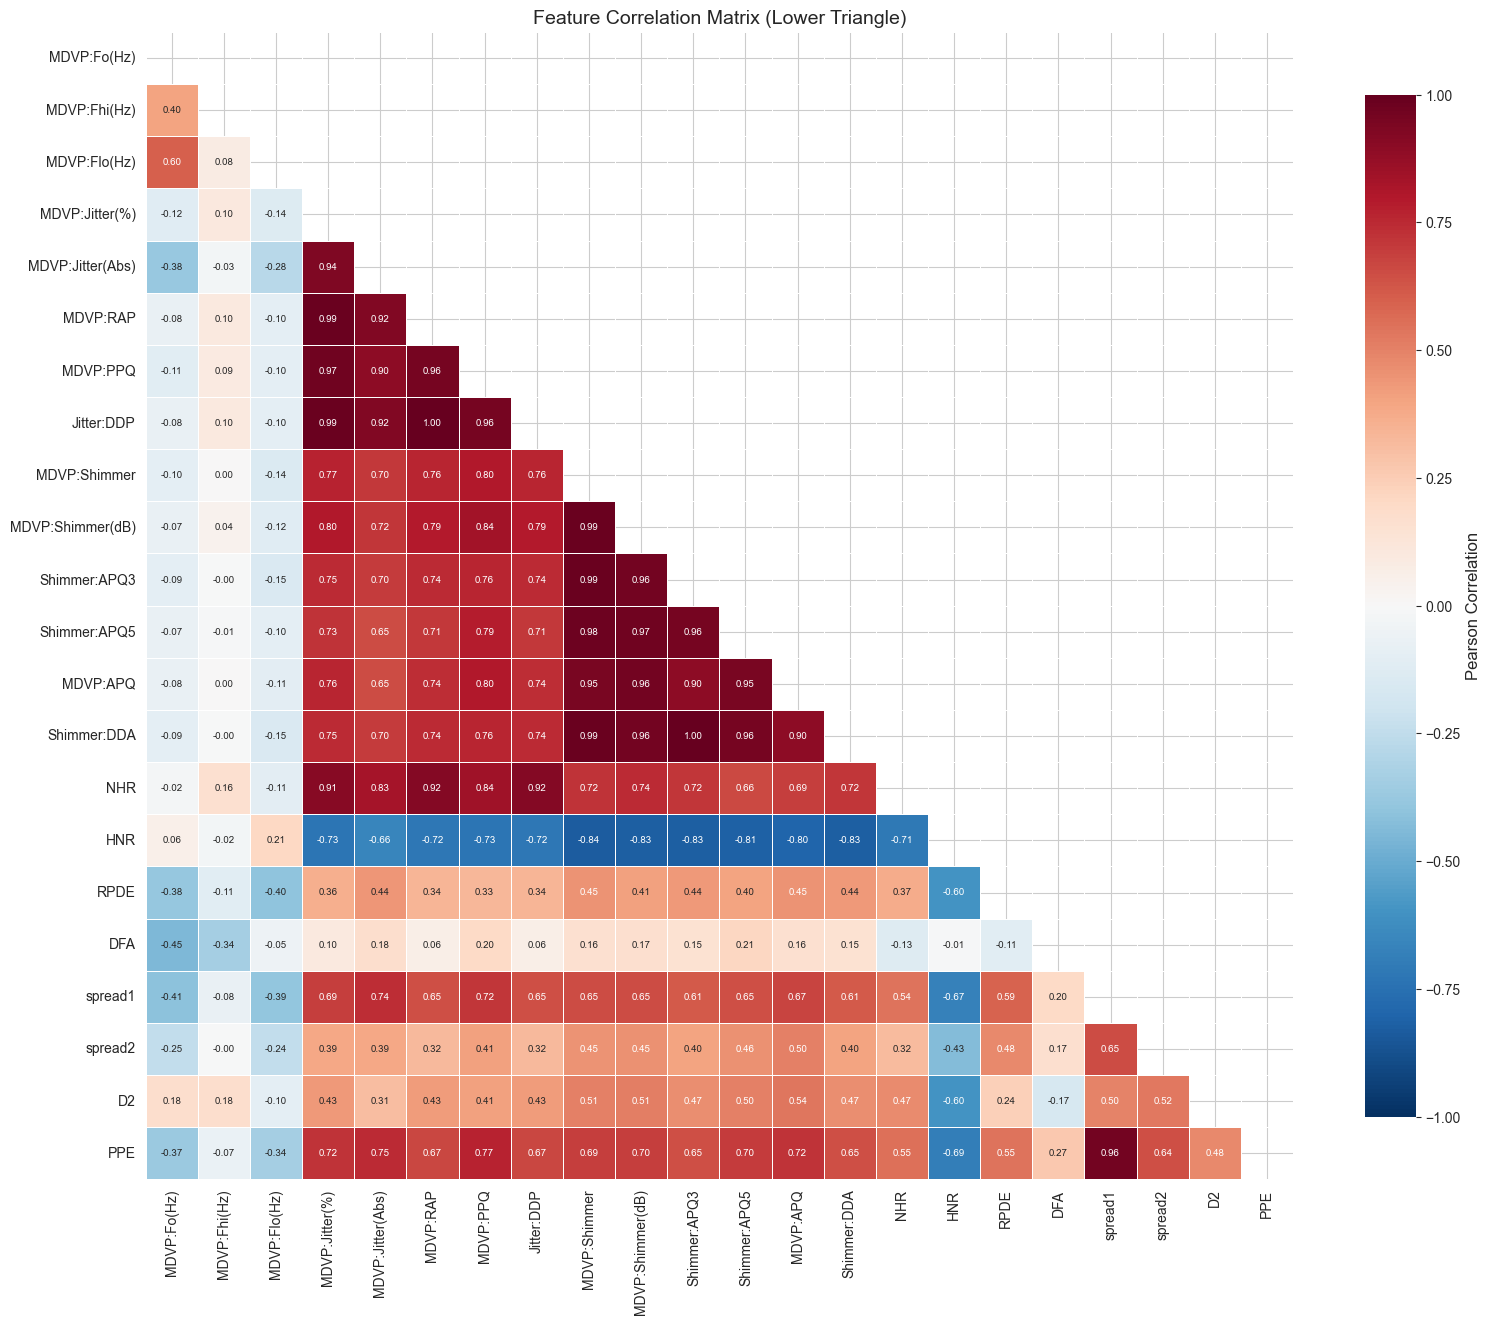

Feature pairs with |correlation| > 0.9:
  Shimmer:APQ3 ↔ Shimmer:DDA: r = 1.0000
  MDVP:RAP ↔ Jitter:DDP: r = 1.0000
  MDVP:Jitter(%) ↔ Jitter:DDP: r = 0.9903
  MDVP:Jitter(%) ↔ MDVP:RAP: r = 0.9903
  MDVP:Shimmer ↔ Shimmer:DDA: r = 0.9876
  MDVP:Shimmer ↔ Shimmer:APQ3: r = 0.9876
  MDVP:Shimmer ↔ MDVP:Shimmer(dB): r = 0.9873
  MDVP:Shimmer ↔ Shimmer:APQ5: r = 0.9828
  MDVP:Jitter(%) ↔ MDVP:PPQ: r = 0.9743
  MDVP:Shimmer(dB) ↔ Shimmer:APQ5: r = 0.9738
  MDVP:Shimmer(dB) ↔ Shimmer:DDA: r = 0.9632
  MDVP:Shimmer(dB) ↔ Shimmer:APQ3: r = 0.9632
  spread1 ↔ PPE: r = 0.9624
  MDVP:Shimmer(dB) ↔ MDVP:APQ: r = 0.9610
  Shimmer:APQ5 ↔ Shimmer:DDA: r = 0.9601
  Shimmer:APQ3 ↔ Shimmer:APQ5: r = 0.9601
  MDVP:PPQ ↔ Jitter:DDP: r = 0.9573
  MDVP:RAP ↔ MDVP:PPQ: r = 0.9573
  MDVP:Shimmer ↔ MDVP:APQ: r = 0.9501
  Shimmer:APQ5 ↔ MDVP:APQ: r = 0.9491
  MDVP:Jitter(%) ↔ MDVP:Jitter(Abs): r = 0.9357
  MDVP:Jitter(Abs) ↔ Jitter:DDP: r = 0.9229
  MDVP:Jitter(Abs) ↔ MDVP:RAP: r = 0.9229
  Jitter:DDP ↔ NHR: 

In [8]:
corr = df[FEATURE_COLS].corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Pearson Correlation'},
            annot_kws={'size': 7}, ax=ax)
ax.set_title('Feature Correlation Matrix (Lower Triangle)', fontsize=14)
plt.tight_layout()
plt.show()

# Highlight high correlations
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.9:
            high_corr_pairs.append(
                (corr.columns[i], corr.columns[j], corr.iloc[i, j]))

print(f'Feature pairs with |correlation| > 0.9:')
for f1, f2, r in sorted(high_corr_pairs, key=lambda x: abs(x[2]),
                         reverse=True):
    print(f'  {f1} \u2194 {f2}: r = {r:.4f}')

### 2.6 Feature Correlation with Target (Status)

Point-biserial correlation between each feature and the PD status label.

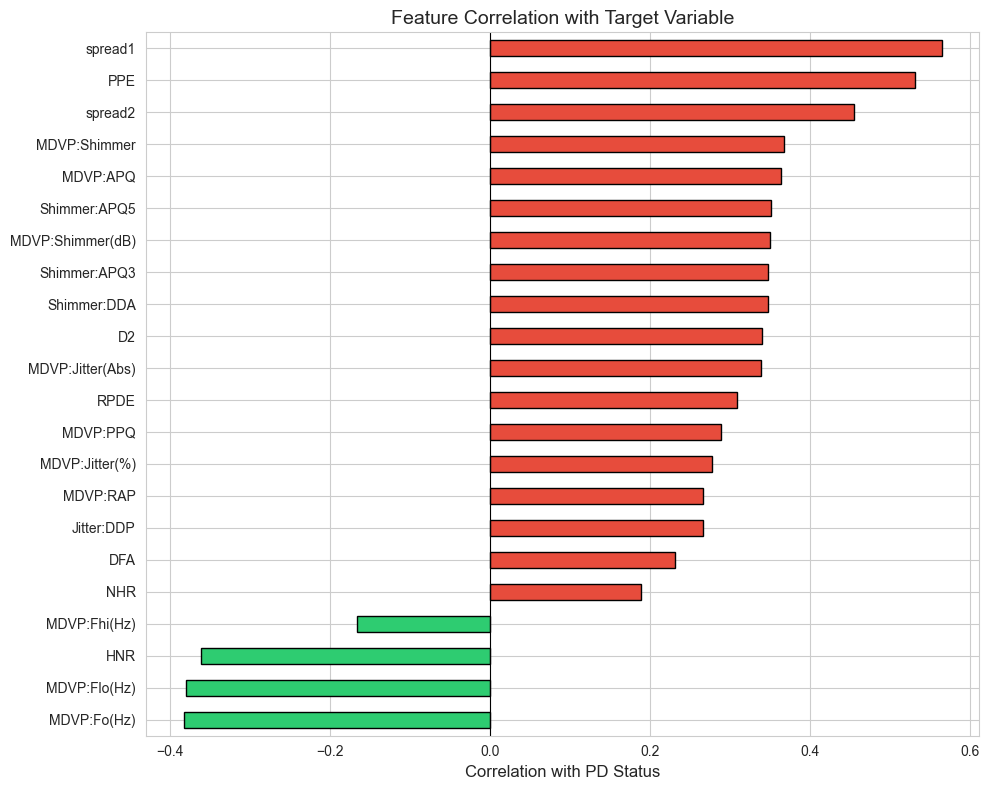

Top 5 most correlated features (absolute value):
  spread1: r = 0.5648 (positive)
  PPE: r = 0.5310 (positive)
  spread2: r = 0.4548 (positive)
  MDVP:Fo(Hz): r = -0.3835 (negative)
  MDVP:Flo(Hz): r = -0.3802 (negative)


In [9]:
corr_with_target = df[FEATURE_COLS].corrwith(df['status']).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
bar_colors = ['#e74c3c' if v > 0 else '#2ecc71'
              for v in corr_with_target.values]
corr_with_target.plot(kind='barh', color=bar_colors, edgecolor='black', ax=ax)
ax.set_xlabel('Correlation with PD Status')
ax.set_title('Feature Correlation with Target Variable')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print('Top 5 most correlated features (absolute value):')
top5 = corr_with_target.abs().sort_values(ascending=False).head(5)
for feat, val in top5.items():
    direction = 'positive' if corr_with_target[feat] > 0 else 'negative'
    print(f'  {feat}: r = {corr_with_target[feat]:.4f} ({direction})')

### 2.7 Known Mathematical Relationships

The jitter and shimmer feature groups contain exact algebraic redundancies:
- `Jitter:DDP = 3 * MDVP:RAP`
- `Shimmer:DDA = 3 * Shimmer:APQ3`

These relationships justify aggressive feature selection.

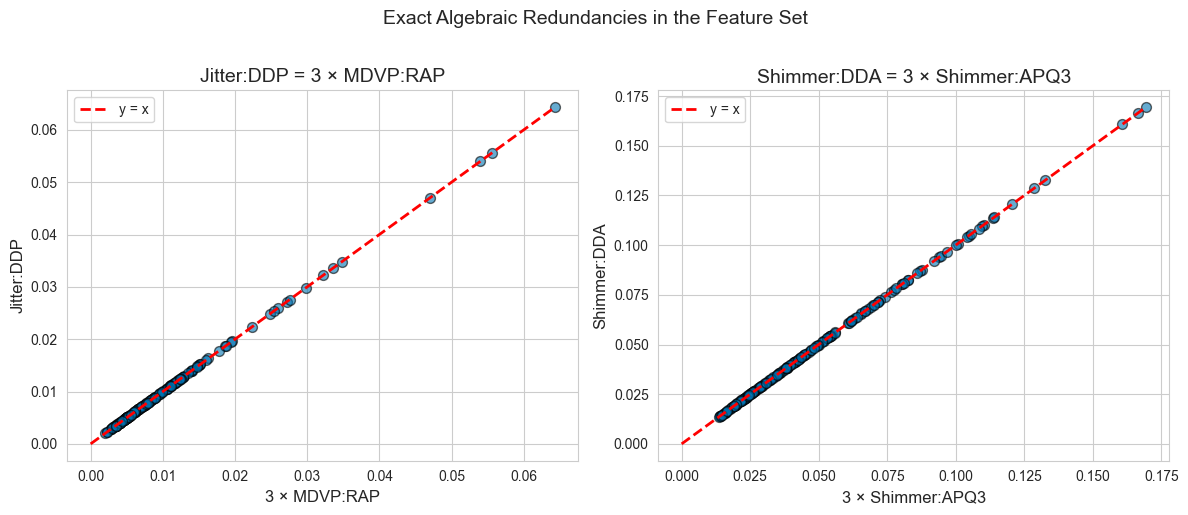

Max |Jitter:DDP - 3*MDVP:RAP|: 1.00e-05
Max |Shimmer:DDA - 3*Shimmer:APQ3|: 1.00e-05


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Jitter:DDP vs 3 * MDVP:RAP
axes[0].scatter(3 * df['MDVP:RAP'], df['Jitter:DDP'],
                alpha=0.6, edgecolors='black', s=50)
lim = df['Jitter:DDP'].max()
axes[0].plot([0, lim], [0, lim], 'r--', lw=2, label='y = x')
axes[0].set_xlabel('3 \u00d7 MDVP:RAP')
axes[0].set_ylabel('Jitter:DDP')
axes[0].set_title('Jitter:DDP = 3 \u00d7 MDVP:RAP')
axes[0].legend()

# Shimmer:DDA vs 3 * Shimmer:APQ3
axes[1].scatter(3 * df['Shimmer:APQ3'], df['Shimmer:DDA'],
                alpha=0.6, edgecolors='black', s=50)
lim2 = df['Shimmer:DDA'].max()
axes[1].plot([0, lim2], [0, lim2], 'r--', lw=2, label='y = x')
axes[1].set_xlabel('3 \u00d7 Shimmer:APQ3')
axes[1].set_ylabel('Shimmer:DDA')
axes[1].set_title('Shimmer:DDA = 3 \u00d7 Shimmer:APQ3')
axes[1].legend()

plt.suptitle('Exact Algebraic Redundancies in the Feature Set',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Verify
diff1 = np.abs(df['Jitter:DDP'] - 3 * df['MDVP:RAP']).max()
diff2 = np.abs(df['Shimmer:DDA'] - 3 * df['Shimmer:APQ3']).max()
print(f'Max |Jitter:DDP - 3*MDVP:RAP|: {diff1:.2e}')
print(f'Max |Shimmer:DDA - 3*Shimmer:APQ3|: {diff2:.2e}')

---
## 3. Data Leakage Demonstration: Record-wise vs Subject-wise CV

With ~6 recordings per subject, a naive random split almost guarantees the same patient
appears in both training and testing folds. The model then memorizes individual vocal
characteristics rather than learning generalizable PD biomarkers.

We demonstrate this using a simple SVM classifier.

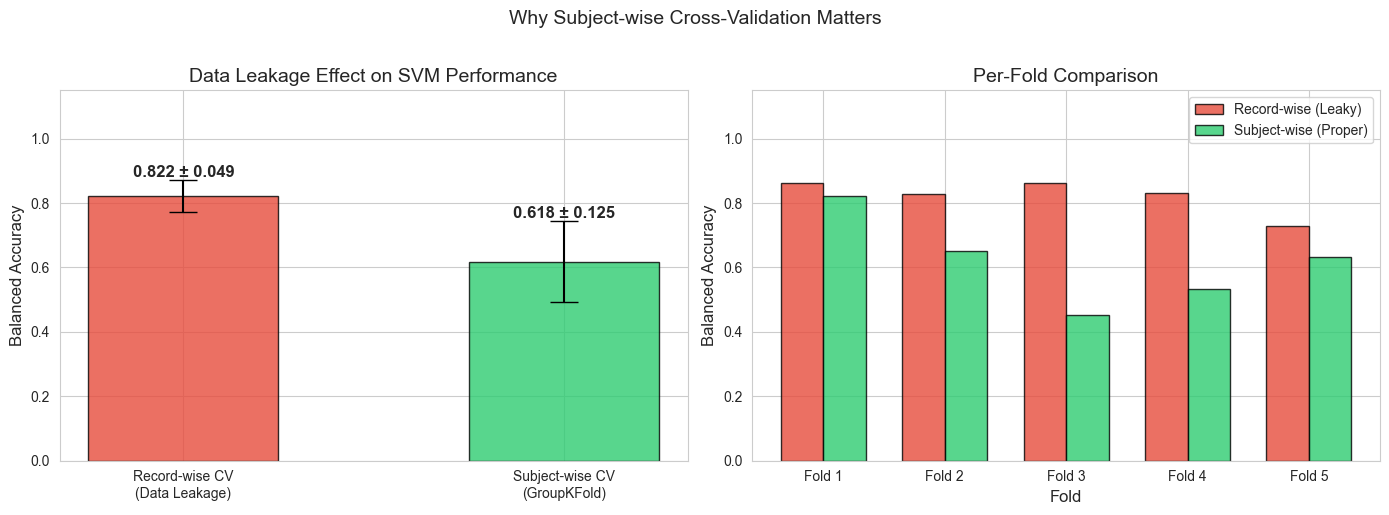

Record-wise CV:  0.8223 ± 0.0487
Subject-wise CV: 0.6182 ± 0.1249
Performance inflation from data leakage: +0.2041 (33.0%)

Conclusion: Record-wise CV inflates results because the model
memorizes speaker-specific traits rather than learning generalizable
PD biomarkers. All subsequent experiments use GroupKFold.


In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Record-wise CV (WRONG: causes data leakage) ---
record_cv = StratifiedKFold(n_splits=5, shuffle=True,
                            random_state=RANDOM_STATE)
svm_leak = SVC(kernel='rbf', C=100, gamma=0.001,
               class_weight='balanced', random_state=RANDOM_STATE)
record_scores = cross_val_score(svm_leak, X_scaled, y,
                                cv=record_cv,
                                scoring='balanced_accuracy')

# --- Subject-wise CV (CORRECT: prevents data leakage) ---
group_cv = GroupKFold(n_splits=5)
svm_proper = SVC(kernel='rbf', C=100, gamma=0.001,
                 class_weight='balanced', random_state=RANDOM_STATE)
group_scores = cross_val_score(svm_proper, X_scaled, y,
                               cv=group_cv,
                               scoring='balanced_accuracy',
                               groups=groups)

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar comparison
methods = ['Record-wise CV\n(Data Leakage)',
           'Subject-wise CV\n(GroupKFold)']
means = [record_scores.mean(), group_scores.mean()]
stds = [record_scores.std(), group_scores.std()]
bar_colors = ['#e74c3c', '#2ecc71']

bars = axes[0].bar(methods, means, yerr=stds, color=bar_colors,
                   edgecolor='black', capsize=10, width=0.5, alpha=0.8)
for bar, mean, std in zip(bars, means, stds):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + std + 0.01,
                 f'{mean:.3f} \u00b1 {std:.3f}',
                 ha='center', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Balanced Accuracy')
axes[0].set_title('Data Leakage Effect on SVM Performance')
axes[0].set_ylim(0, 1.15)

# Fold-by-fold
x_pos = np.arange(5)
width = 0.35
axes[1].bar(x_pos - width/2, record_scores, width,
            label='Record-wise (Leaky)', color='#e74c3c',
            alpha=0.8, edgecolor='black')
axes[1].bar(x_pos + width/2, group_scores, width,
            label='Subject-wise (Proper)', color='#2ecc71',
            alpha=0.8, edgecolor='black')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('Balanced Accuracy')
axes[1].set_title('Per-Fold Comparison')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([f'Fold {i+1}' for i in range(5)])
axes[1].legend()
axes[1].set_ylim(0, 1.15)

plt.suptitle('Why Subject-wise Cross-Validation Matters',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

drop = means[0] - means[1]
print(f'Record-wise CV:  {means[0]:.4f} \u00b1 {stds[0]:.4f}')
print(f'Subject-wise CV: {means[1]:.4f} \u00b1 {stds[1]:.4f}')
print(f'Performance inflation from data leakage: '
      f'+{drop:.4f} ({drop/means[1]*100:.1f}%)')
print()
print('Conclusion: Record-wise CV inflates results because the model')
print('memorizes speaker-specific traits rather than learning generalizable')
print('PD biomarkers. All subsequent experiments use GroupKFold.')

---
## 4. Feature Selection

We compare two strategies:
1. **PCA** — unsupervised, selects components explaining ≥95% variance
2. **SVM-RFE** — supervised wrapper using SVM to recursively eliminate least important features

Both are evaluated within subject-wise GroupKFold to prevent information leakage.

### 4.1 PCA — Principal Component Analysis

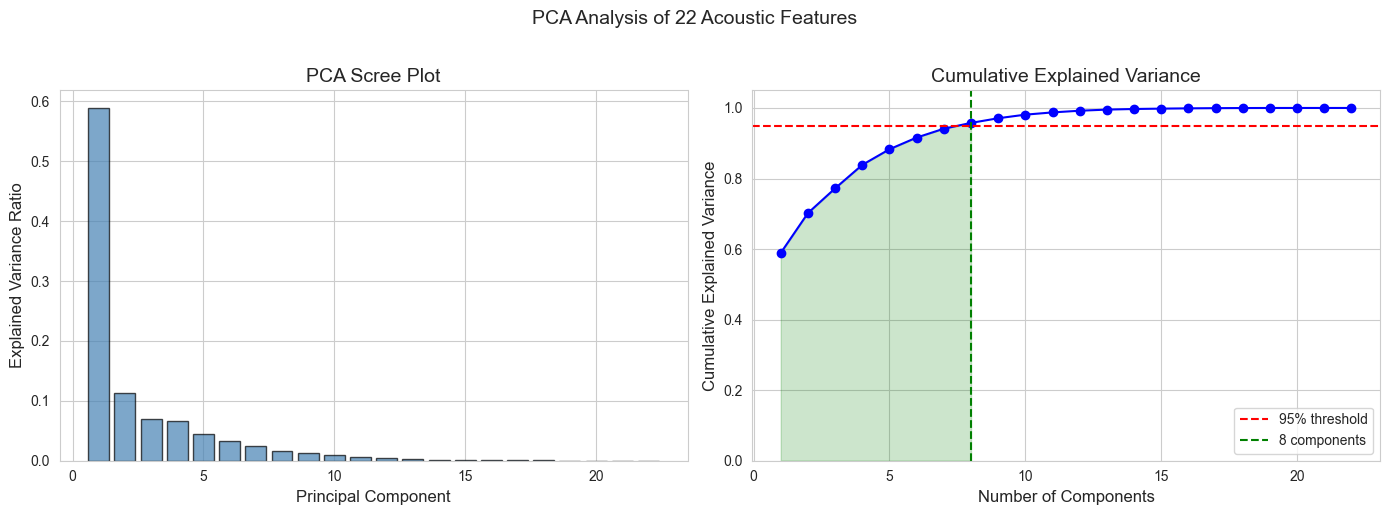

Components needed for 95% variance: 8
Variance explained by 8 components: 95.77%


In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_95 = np.argmax(cumvar >= 0.95) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
            pca_full.explained_variance_ratio_,
            color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('PCA Scree Plot')

# Cumulative variance
axes[1].plot(range(1, len(cumvar) + 1), cumvar, 'bo-', markersize=6)
axes[1].axhline(y=0.95, color='red', linestyle='--',
                label='95% threshold')
axes[1].axvline(x=n_95, color='green', linestyle='--',
                label=f'{n_95} components')
axes[1].fill_between(range(1, n_95 + 1), cumvar[:n_95],
                     alpha=0.2, color='green')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()
axes[1].set_ylim(0, 1.05)

plt.suptitle('PCA Analysis of 22 Acoustic Features',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'Components needed for 95% variance: {n_95}')
print(f'Variance explained by {n_95} components: '
      f'{cumvar[n_95 - 1]*100:.2f}%')

PCA_N_COMPONENTS = n_95

### 4.2 SVM-RFE — Recursive Feature Elimination with SVM

We run SVM-RFE inside each fold of 5-fold GroupKFold and track which features are
consistently selected across folds. Features selected in ≥3 of 5 folds are kept.

Fold 1: ['MDVP:Fo(Hz)', 'MDVP:Flo(Hz)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:APQ', 'HNR', 'spread1', 'D2']
Fold 2: ['MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'Jitter:DDP', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'spread1', 'D2', 'PPE']
Fold 3: ['MDVP:Fo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'Jitter:DDP', 'MDVP:APQ', 'RPDE', 'spread1', 'spread2', 'PPE']
Fold 4: ['MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer(dB)', 'Shimmer:APQ5', 'MDVP:APQ', 'NHR', 'spread1', 'D2']
Fold 5: ['MDVP:Jitter(%)', 'MDVP:PPQ', 'Shimmer:APQ5', 'MDVP:APQ', 'NHR', 'HNR', 'DFA', 'spread2', 'D2', 'PPE']


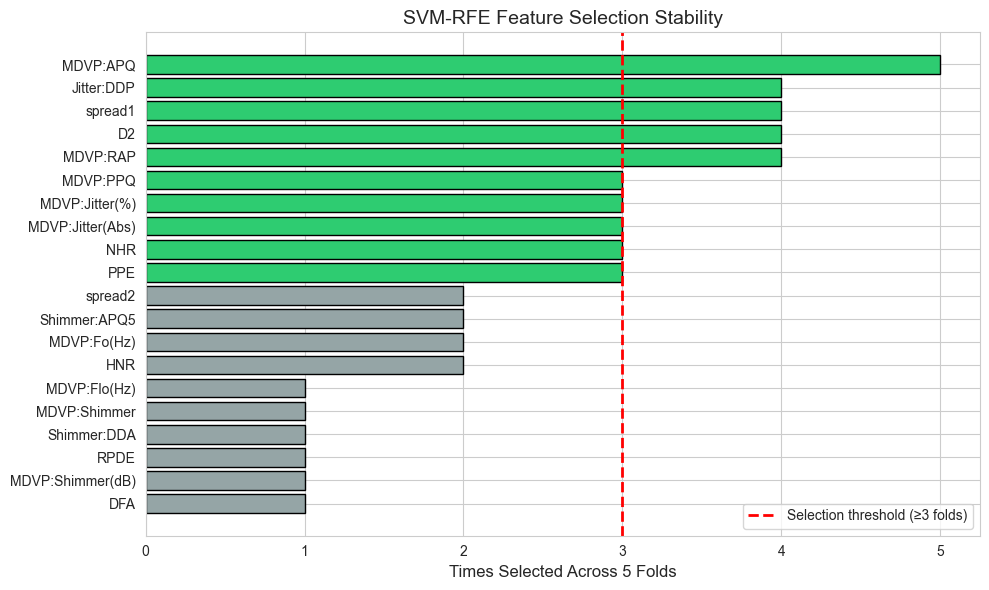


SVM-RFE selected features (10):
  ['MDVP:APQ', 'Jitter:DDP', 'spread1', 'D2', 'MDVP:RAP', 'MDVP:PPQ', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'NHR', 'PPE']


In [13]:
from collections import Counter

group_cv = GroupKFold(n_splits=5)
feature_names = np.array(FEATURE_COLS)
rfe_selections = []

for fold_idx, (train_idx, test_idx) in enumerate(
        group_cv.split(X, y, groups)):
    X_train_fold = X[train_idx]
    y_train_fold = y[train_idx]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_fold)

    svm_rfe = SVC(kernel='linear', C=1, class_weight='balanced',
                  random_state=RANDOM_STATE)
    rfe = RFE(estimator=svm_rfe, n_features_to_select=10, step=1)
    rfe.fit(X_train_scaled, y_train_fold)

    selected = feature_names[rfe.support_].tolist()
    rfe_selections.append(selected)
    print(f'Fold {fold_idx + 1}: {selected}')

# Count feature selections across folds
all_selected = [f for fold_feats in rfe_selections for f in fold_feats]
feature_counts = Counter(all_selected)
feature_count_df = pd.DataFrame([
    {'feature': f, 'times_selected': c}
    for f, c in feature_counts.most_common()
]).sort_values('times_selected', ascending=False)

# Features selected in >= 3 folds
SVM_RFE_FEATURES = feature_count_df[
    feature_count_df['times_selected'] >= 3
]['feature'].tolist()

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = ['#2ecc71' if c >= 3 else '#95a5a6'
              for c in feature_count_df['times_selected']]
ax.barh(feature_count_df['feature'],
        feature_count_df['times_selected'],
        color=bar_colors, edgecolor='black')
ax.axvline(x=3, color='red', linestyle='--', linewidth=2,
           label='Selection threshold (\u22653 folds)')
ax.set_xlabel('Times Selected Across 5 Folds')
ax.set_title('SVM-RFE Feature Selection Stability')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f'\nSVM-RFE selected features ({len(SVM_RFE_FEATURES)}):')
print(f'  {SVM_RFE_FEATURES}')

### 4.3 Feature Selection Comparison: All Features vs PCA vs SVM-RFE

We evaluate a simple SVM classifier under each feature strategy using subject-wise GroupKFold.

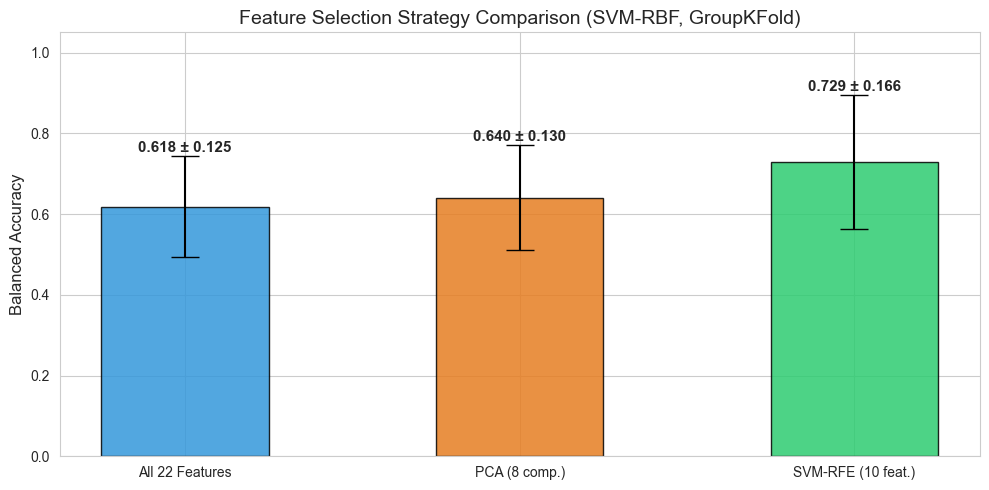

All 22 Features: 0.6182 ± 0.1249
PCA (8 comp.): 0.6399 ± 0.1300
SVM-RFE (10 feat.): 0.7288 ± 0.1662


In [14]:
group_cv = GroupKFold(n_splits=5)
strategies = {}

# Strategy 1: All features
pipe_all = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel='rbf', C=100, gamma=0.001,
                class_weight='balanced', random_state=RANDOM_STATE))
])
scores_all = cross_val_score(pipe_all, X, y, cv=group_cv,
                             groups=groups,
                             scoring='balanced_accuracy')
strategies['All 22 Features'] = scores_all

# Strategy 2: PCA
pipe_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=PCA_N_COMPONENTS,
                random_state=RANDOM_STATE)),
    ('clf', SVC(kernel='rbf', C=100, gamma=0.001,
                class_weight='balanced', random_state=RANDOM_STATE))
])
scores_pca = cross_val_score(pipe_pca, X, y, cv=group_cv,
                             groups=groups,
                             scoring='balanced_accuracy')
strategies[f'PCA ({PCA_N_COMPONENTS} comp.)'] = scores_pca

# Strategy 3: SVM-RFE selected features
X_rfe = df[SVM_RFE_FEATURES].values
pipe_rfe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel='rbf', C=100, gamma=0.001,
                class_weight='balanced', random_state=RANDOM_STATE))
])
scores_rfe = cross_val_score(pipe_rfe, X_rfe, y, cv=group_cv,
                             groups=groups,
                             scoring='balanced_accuracy')
strategies[f'SVM-RFE ({len(SVM_RFE_FEATURES)} feat.)'] = scores_rfe

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
names = list(strategies.keys())
means = [v.mean() for v in strategies.values()]
stds = [v.std() for v in strategies.values()]
bar_colors = ['#3498db', '#e67e22', '#2ecc71']

bars = ax.bar(range(len(names)), means, yerr=stds,
              color=bar_colors, edgecolor='black',
              capsize=10, width=0.5, alpha=0.85)
for bar, m, s in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.01,
            f'{m:.3f} \u00b1 {s:.3f}',
            ha='center', fontsize=11, fontweight='bold')
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names)
ax.set_ylabel('Balanced Accuracy')
ax.set_title('Feature Selection Strategy Comparison '
             '(SVM-RBF, GroupKFold)')
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

for name, scores in strategies.items():
    print(f'{name}: {scores.mean():.4f} \u00b1 {scores.std():.4f}')

---
## 5. Stacking Ensemble Classifier

### Architecture

We build a two-level stacking ensemble:

**Level 0 — Base Learners** (4 classifiers with tuned hyperparameters from nested CV):
1. **SVM-RBF**: C=100, gamma=0.001, class_weight='balanced'
2. **KNN**: n_neighbors=15, weights='uniform', metric='euclidean'
3. **Random Forest**: n_estimators=50, max_depth=3, min_samples_leaf=2,
   min_samples_split=10, class_weight='balanced'
4. **Logistic Regression (L1)**: C=1, solver='saga', class_weight='balanced'

**Level 1 — Meta-Learner**: Logistic Regression (L2), C=0.1, class_weight='balanced'

Meta-features are out-of-fold predicted probabilities generated via internal
5-fold GroupKFold. All experiments use subject-wise GroupKFold in the outer loop.

In [15]:
# Define base learners with tuned hyperparameters
BASE_LEARNERS = {
    'SVM_RBF': SVC(
        kernel='rbf', C=100, gamma=0.001,
        class_weight='balanced', probability=True,
        random_state=RANDOM_STATE
    ),
    'KNN': KNeighborsClassifier(
        n_neighbors=15, weights='uniform', metric='euclidean'
    ),
    'Random_Forest': RandomForestClassifier(
        n_estimators=50, max_depth=3,
        min_samples_leaf=2, min_samples_split=10,
        class_weight='balanced', random_state=RANDOM_STATE
    ),
    'Logistic_L1': LogisticRegression(
        penalty='l1', C=1, solver='saga',
        class_weight='balanced', max_iter=5000,
        random_state=RANDOM_STATE
    ),
}

# Meta-learner
META_LEARNER = LogisticRegression(
    penalty='l2', C=0.1, solver='lbfgs',
    class_weight='balanced', max_iter=5000,
    random_state=RANDOM_STATE
)

# Use SVM-RFE features
X_stack = df[SVM_RFE_FEATURES].values

print('Stacking Ensemble Configuration')
print('=' * 50)
print(f'Feature set: SVM-RFE ({len(SVM_RFE_FEATURES)} features)')
print(f'Features: {SVM_RFE_FEATURES}')
print(f'\nBase learners: {list(BASE_LEARNERS.keys())}')
print(f'Meta-learner: Logistic Regression L2 (C=0.1)')
print(f'Inner CV: 5-fold GroupKFold')
print(f'Outer CV: 5-fold GroupKFold')

Stacking Ensemble Configuration
Feature set: SVM-RFE (10 features)
Features: ['MDVP:APQ', 'Jitter:DDP', 'spread1', 'D2', 'MDVP:RAP', 'MDVP:PPQ', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'NHR', 'PPE']

Base learners: ['SVM_RBF', 'KNN', 'Random_Forest', 'Logistic_L1']
Meta-learner: Logistic Regression L2 (C=0.1)
Inner CV: 5-fold GroupKFold
Outer CV: 5-fold GroupKFold


In [16]:
def generate_meta_features(X_train, y_train, groups_train,
                           base_learners, n_inner_folds=5):
    """
    Generate out-of-fold predicted probabilities from base learners
    using inner GroupKFold. These become the meta-features for the
    Level-1 meta-learner.
    """
    n_samples = len(y_train)
    n_base = len(base_learners)
    meta_features = np.zeros((n_samples, n_base))

    inner_cv = GroupKFold(n_splits=n_inner_folds)

    for learner_idx, (name, clf) in enumerate(base_learners.items()):
        for inner_train_idx, inner_val_idx in inner_cv.split(
                X_train, y_train, groups_train):
            X_inner_train = X_train[inner_train_idx]
            y_inner_train = y_train[inner_train_idx]
            X_inner_val = X_train[inner_val_idx]

            scaler = StandardScaler()
            X_inner_train_scaled = scaler.fit_transform(X_inner_train)
            X_inner_val_scaled = scaler.transform(X_inner_val)

            model = clone(clf)
            model.fit(X_inner_train_scaled, y_inner_train)

            proba = model.predict_proba(X_inner_val_scaled)[:, 1]
            meta_features[inner_val_idx, learner_idx] = proba

    return meta_features


def run_stacking_cv(X, y, groups, base_learners, meta_learner,
                    n_outer_folds=5, n_inner_folds=5):
    """
    Full stacking evaluation with subject-wise GroupKFold at both levels.
    Outer loop: evaluates the complete stacking ensemble.
    Inner loop: generates out-of-fold meta-features from base learners.
    """
    outer_cv = GroupKFold(n_splits=n_outer_folds)

    all_y_true = []
    all_y_pred = []
    all_y_proba = []
    fold_results = []

    # Track individual base learner predictions for comparison
    base_preds = {name: [] for name in base_learners}
    base_y_true_dict = {name: [] for name in base_learners}

    for fold_idx, (train_idx, test_idx) in enumerate(
            outer_cv.split(X, y, groups)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        groups_train = (groups.iloc[train_idx]
                        if hasattr(groups, 'iloc')
                        else groups[train_idx])

        print(f'Outer Fold {fold_idx + 1}: '
              f'Train={len(train_idx)}, Test={len(test_idx)}, '
              f'PD train={y_train.sum()}, '
              f'Healthy train={(y_train == 0).sum()}, '
              f'PD test={y_test.sum()}, '
              f'Healthy test={(y_test == 0).sum()}')

        # Step 1: Generate meta-features from inner CV
        meta_train = generate_meta_features(
            X_train, y_train, groups_train,
            base_learners, n_inner_folds
        )

        # Step 2: Train base learners on full outer training set
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        meta_test = np.zeros((len(test_idx), len(base_learners)))
        for learner_idx, (name, clf) in enumerate(
                base_learners.items()):
            model = clone(clf)
            model.fit(X_train_scaled, y_train)
            meta_test[:, learner_idx] = (
                model.predict_proba(X_test_scaled)[:, 1]
            )

            # Track individual base learner predictions
            base_preds[name].extend(
                model.predict(X_test_scaled).tolist())
            base_y_true_dict[name].extend(y_test.tolist())

        # Step 3: Train meta-learner and predict
        meta_model = clone(meta_learner)
        meta_model.fit(meta_train, y_train)

        y_pred = meta_model.predict(meta_test)
        y_proba = meta_model.predict_proba(meta_test)[:, 1]

        all_y_true.extend(y_test.tolist())
        all_y_pred.extend(y_pred.tolist())
        all_y_proba.extend(y_proba.tolist())

        # Fold metrics
        fold_ba = balanced_accuracy_score(y_test, y_pred)
        fold_sens = recall_score(y_test, y_pred, pos_label=1,
                                 zero_division=0)
        fold_spec = recall_score(y_test, y_pred, pos_label=0,
                                 zero_division=0)
        fold_results.append({
            'fold': fold_idx + 1,
            'balanced_accuracy': fold_ba,
            'sensitivity': fold_sens,
            'specificity': fold_spec,
            'meta_learner_coefs': meta_model.coef_[0].tolist()
        })
        print(f'  -> BA={fold_ba:.4f}, '
              f'Sens={fold_sens:.4f}, Spec={fold_spec:.4f}')
        coef_dict = dict(zip(base_learners.keys(),
                             meta_model.coef_[0].round(3)))
        print(f'  -> Meta-learner weights: {coef_dict}')
        print()

    return (np.array(all_y_true), np.array(all_y_pred),
            np.array(all_y_proba), fold_results,
            base_preds, base_y_true_dict)

In [17]:
# Run stacking
print('=' * 60)
print('  STACKING ENSEMBLE — Subject-wise GroupKFold')
print('=' * 60)
print()

y_true, y_pred, y_proba, fold_results, base_preds, base_y_true_dict = (
    run_stacking_cv(
        X_stack, y, groups, BASE_LEARNERS, META_LEARNER,
        n_outer_folds=5, n_inner_folds=5
    )
)

  STACKING ENSEMBLE — Subject-wise GroupKFold

Outer Fold 1: Train=158, Test=37, PD train=116, Healthy train=42, PD test=31, Healthy test=6
  -> BA=0.9194, Sens=0.8387, Spec=1.0000
  -> Meta-learner weights: {'SVM_RBF': 0.444, 'KNN': 0.458, 'Random_Forest': 0.488, 'Logistic_L1': 0.87}

Outer Fold 2: Train=158, Test=37, PD train=122, Healthy train=36, PD test=25, Healthy test=12
  -> BA=0.7733, Sens=0.8800, Spec=0.6667
  -> Meta-learner weights: {'SVM_RBF': 0.393, 'KNN': 0.158, 'Random_Forest': 0.361, 'Logistic_L1': 0.828}

Outer Fold 3: Train=158, Test=37, PD train=116, Healthy train=42, PD test=31, Healthy test=6
  -> BA=0.5188, Sens=0.8710, Spec=0.1667
  -> Meta-learner weights: {'SVM_RBF': 0.525, 'KNN': 0.42, 'Random_Forest': 0.6, 'Logistic_L1': 0.804}

Outer Fold 4: Train=153, Test=42, PD train=117, Healthy train=36, PD test=30, Healthy test=12
  -> BA=0.5833, Sens=0.5000, Spec=0.6667
  -> Meta-learner weights: {'SVM_RBF': 0.546, 'KNN': 0.443, 'Random_Forest': 0.068, 'Logistic_L1':

---
## 6. Evaluation Metrics & Results

In [18]:
def compute_all_metrics(y_true, y_pred, y_proba=None):
    """Compute comprehensive evaluation metrics."""
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Balanced Accuracy': balanced_accuracy_score(y_true, y_pred),
        'Sensitivity (Recall)': recall_score(
            y_true, y_pred, pos_label=1, zero_division=0),
        'Specificity': recall_score(
            y_true, y_pred, pos_label=0, zero_division=0),
        'Precision': precision_score(
            y_true, y_pred, pos_label=1, zero_division=0),
        'F1-Score': f1_score(
            y_true, y_pred, pos_label=1, zero_division=0),
        'MCC': matthews_corrcoef(y_true, y_pred),
    }
    if y_proba is not None:
        metrics['AUC-ROC'] = roc_auc_score(y_true, y_proba)
    return metrics


# --- Ensemble metrics ---
ensemble_metrics = compute_all_metrics(y_true, y_pred, y_proba)

print('=' * 50)
print('  STACKING ENSEMBLE — Overall Results')
print('=' * 50)
for metric, value in ensemble_metrics.items():
    print(f'  {metric:25s}: {value:.4f}')

# --- Per-fold summary ---
print(f'\n--- Per-Fold Breakdown ---')
fold_df = pd.DataFrame(fold_results)
print(fold_df[['fold', 'balanced_accuracy',
               'sensitivity', 'specificity']].to_string(index=False))
print(f'\nMean BA:   '
      f'{fold_df["balanced_accuracy"].mean():.4f} '
      f'\u00b1 {fold_df["balanced_accuracy"].std():.4f}')
print(f'Mean Sens: '
      f'{fold_df["sensitivity"].mean():.4f} '
      f'\u00b1 {fold_df["sensitivity"].std():.4f}')
print(f'Mean Spec: '
      f'{fold_df["specificity"].mean():.4f} '
      f'\u00b1 {fold_df["specificity"].std():.4f}')

  STACKING ENSEMBLE — Overall Results
  Accuracy                 : 0.7744
  Balanced Accuracy        : 0.7591
  Sensitivity (Recall)     : 0.7891
  Specificity              : 0.7292
  Precision                : 0.8992
  F1-Score                 : 0.8406
  MCC                      : 0.4718
  AUC-ROC                  : 0.8407

--- Per-Fold Breakdown ---
 fold  balanced_accuracy  sensitivity  specificity
    1           0.919355     0.838710     1.000000
    2           0.773333     0.880000     0.666667
    3           0.518817     0.870968     0.166667
    4           0.583333     0.500000     0.666667
    5           0.933333     0.866667     1.000000

Mean BA:   0.7456 ± 0.1897
Mean Sens: 0.7913 ± 0.1636
Mean Spec: 0.7000 ± 0.3416


### 6.1 Confusion Matrix

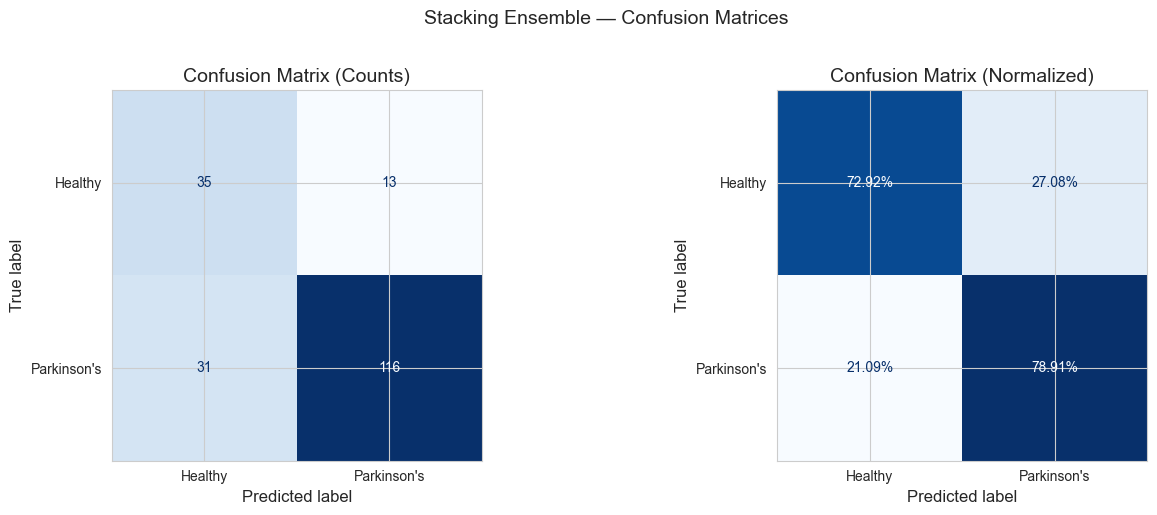

True Positives: 116  |  False Negatives: 31
True Negatives: 35  |  False Positives: 13


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Counts
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(cm,
                              display_labels=['Healthy', "Parkinson's"])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix (Counts)')

# Normalized
cm_norm = confusion_matrix(y_true, y_pred, labels=[0, 1],
                           normalize='true')
disp_norm = ConfusionMatrixDisplay(
    cm_norm, display_labels=['Healthy', "Parkinson's"])
disp_norm.plot(ax=axes[1], cmap='Blues', colorbar=False,
               values_format='.2%')
axes[1].set_title('Confusion Matrix (Normalized)')

plt.suptitle('Stacking Ensemble — Confusion Matrices',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'True Positives: {cm[1,1]}  |  False Negatives: {cm[1,0]}')
print(f'True Negatives: {cm[0,0]}  |  False Positives: {cm[0,1]}')

### 6.2 ROC Curve

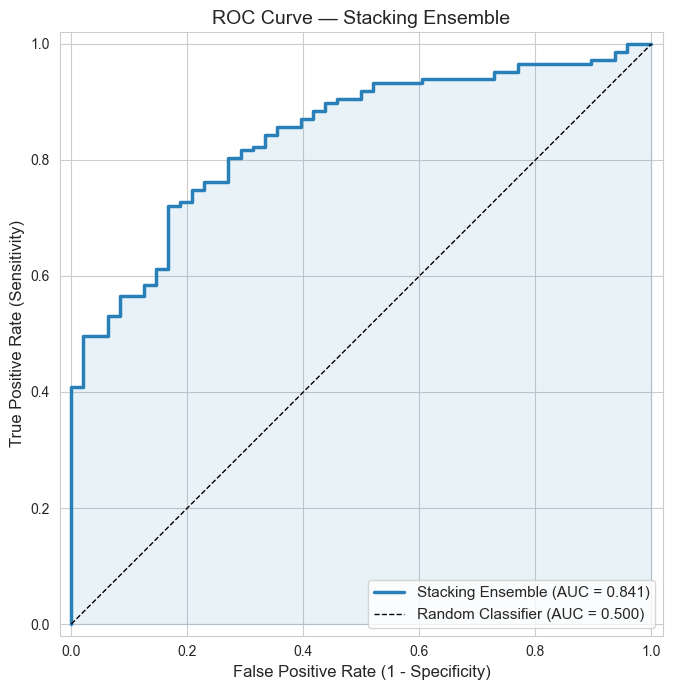

In [20]:
fpr, tpr, thresholds = roc_curve(y_true, y_proba)
auc_val = roc_auc_score(y_true, y_proba)

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(fpr, tpr, color='#2980b9', lw=2.5,
        label=f'Stacking Ensemble (AUC = {auc_val:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1,
        label='Random Classifier (AUC = 0.500)')
ax.fill_between(fpr, tpr, alpha=0.1, color='#2980b9')
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.set_title('ROC Curve — Stacking Ensemble')
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

### 6.3 Ensemble vs Individual Base Learners

Comparing the stacking ensemble against each individual base learner.

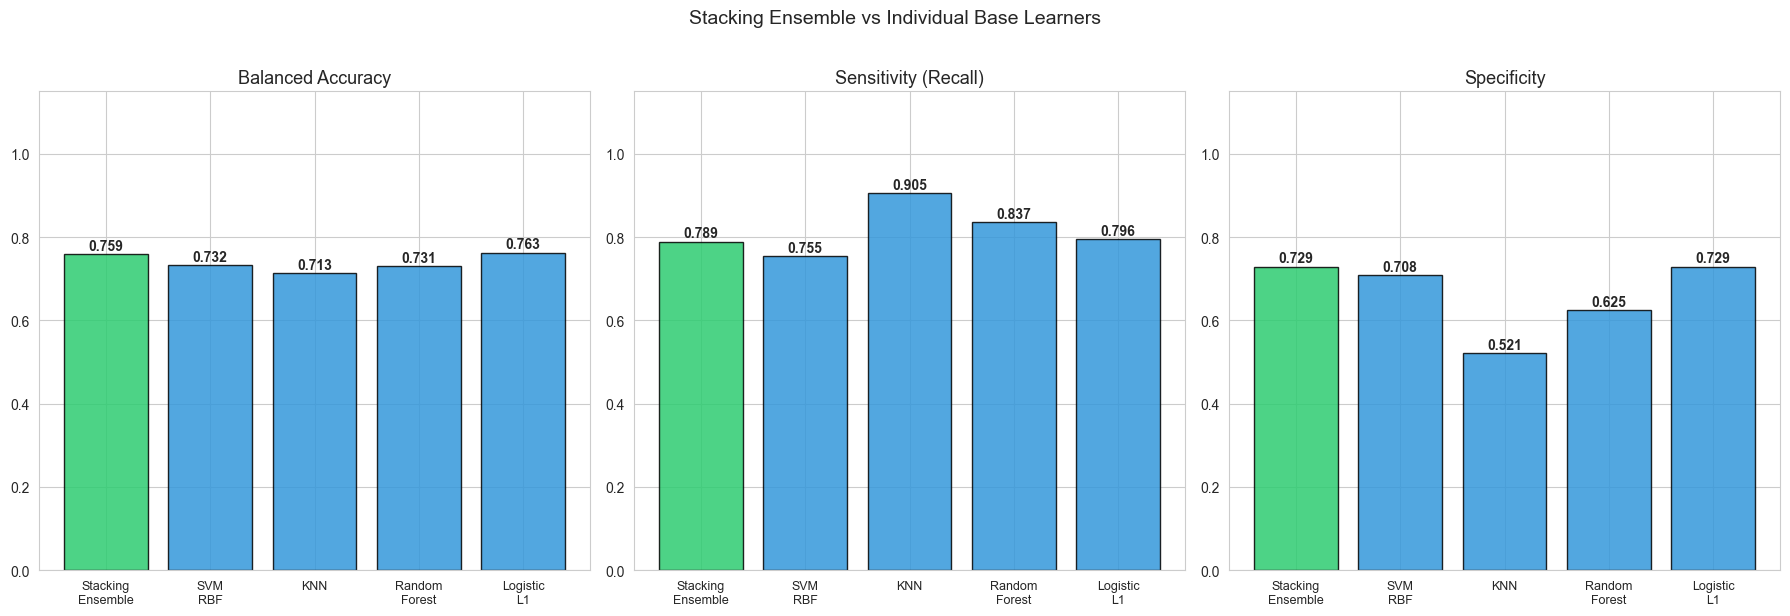

Full Comparison Table:
                    Accuracy  Balanced Accuracy  Sensitivity (Recall)  Specificity  Precision  F1-Score     MCC  AUC-ROC
Stacking\nEnsemble    0.7744             0.7591                0.7891       0.7292     0.8992    0.8406  0.4718   0.8407
SVM\nRBF              0.7436             0.7317                0.7551       0.7083     0.8880    0.8162  0.4162      NaN
KNN                   0.8103             0.7128                0.9048       0.5208     0.8526    0.8779  0.4583      NaN
Random\nForest        0.7846             0.7309                0.8367       0.6250     0.8723    0.8542  0.4445      NaN
Logistic\nL1          0.7795             0.7625                0.7959       0.7292     0.9000    0.8448  0.4798      NaN


In [21]:
comparison = {}

# Ensemble
comparison['Stacking\nEnsemble'] = compute_all_metrics(
    y_true, y_pred, y_proba)

# Individual base learners
for name in BASE_LEARNERS:
    bt = np.array(base_y_true_dict[name])
    bp = np.array(base_preds[name])
    comparison[name.replace('_', '\n')] = compute_all_metrics(bt, bp)

comp_df = pd.DataFrame(comparison).T

# Plot key metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics_to_plot = ['Balanced Accuracy', 'Sensitivity (Recall)',
                   'Specificity']
plot_colors = (['#2ecc71'] +
               ['#3498db'] * len(BASE_LEARNERS))

for ax, metric in zip(axes, metrics_to_plot):
    values = comp_df[metric].values
    names = comp_df.index
    bars = ax.bar(range(len(names)), values,
                  color=plot_colors, edgecolor='black', alpha=0.85)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', fontsize=10,
                fontweight='bold')
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, fontsize=9)
    ax.set_title(metric, fontsize=13)
    ax.set_ylim(0, 1.15)

plt.suptitle('Stacking Ensemble vs Individual Base Learners',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('Full Comparison Table:')
print(comp_df.round(4).to_string())

### 6.4 Meta-Learner Weights Analysis

The meta-learner's coefficients reveal how much it relies on each base learner's predictions.

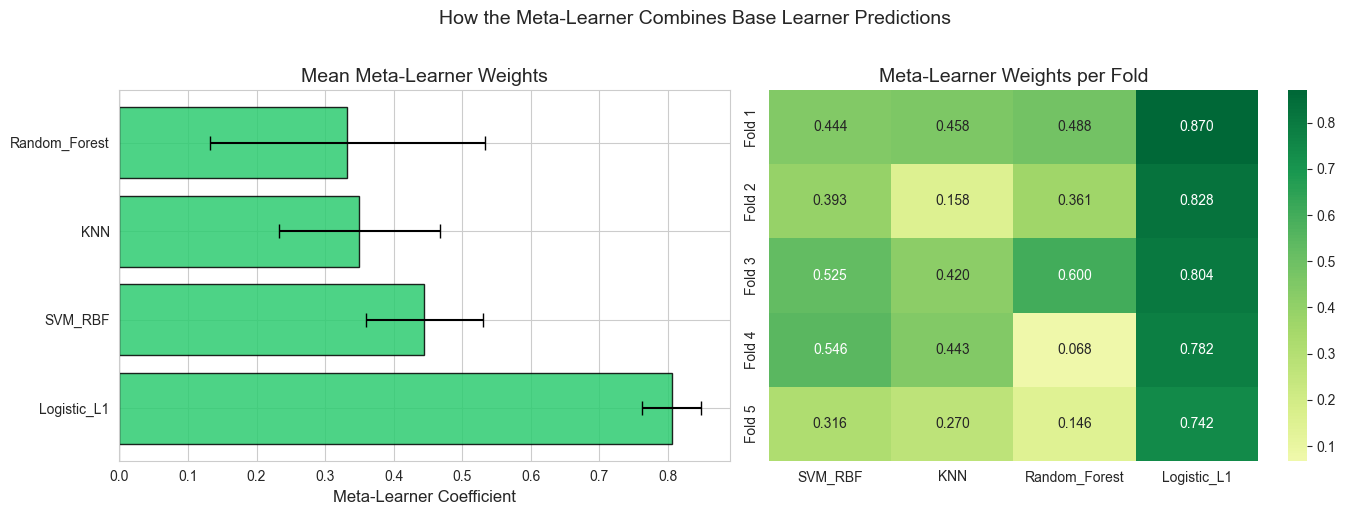

Mean meta-learner weights:
  SVM_RBF             : +0.4447 ± 0.0849
  KNN                 : +0.3500 ± 0.1172
  Random_Forest       : +0.3325 ± 0.2006
  Logistic_L1         : +0.8053 ± 0.0431


In [22]:
coefs_per_fold = np.array(
    [fr['meta_learner_coefs'] for fr in fold_results])
base_names = list(BASE_LEARNERS.keys())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean weights
mean_coefs = coefs_per_fold.mean(axis=0)
std_coefs = coefs_per_fold.std(axis=0)
sorted_idx = np.argsort(np.abs(mean_coefs))[::-1]

ax = axes[0]
colors_coef = ['#2ecc71' if mean_coefs[i] > 0 else '#e74c3c'
               for i in sorted_idx]
ax.barh(range(len(base_names)),
        [mean_coefs[i] for i in sorted_idx],
        xerr=[std_coefs[i] for i in sorted_idx],
        color=colors_coef, edgecolor='black',
        capsize=5, alpha=0.85)
ax.set_yticks(range(len(base_names)))
ax.set_yticklabels([base_names[i] for i in sorted_idx])
ax.set_xlabel('Meta-Learner Coefficient')
ax.set_title('Mean Meta-Learner Weights')
ax.axvline(x=0, color='black', linewidth=0.8)

# Per-fold heatmap
ax2 = axes[1]
sns.heatmap(coefs_per_fold, annot=True, fmt='.3f',
            cmap='RdYlGn', center=0,
            xticklabels=base_names,
            yticklabels=[f'Fold {i+1}'
                         for i in range(len(fold_results))],
            ax=ax2)
ax2.set_title('Meta-Learner Weights per Fold')

plt.suptitle('How the Meta-Learner Combines Base Learner Predictions',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('Mean meta-learner weights:')
for name, coef, std in zip(base_names, mean_coefs, std_coefs):
    print(f'  {name:20s}: {coef:+.4f} \u00b1 {std:.4f}')

### 6.5 Per-Fold Performance Visualization

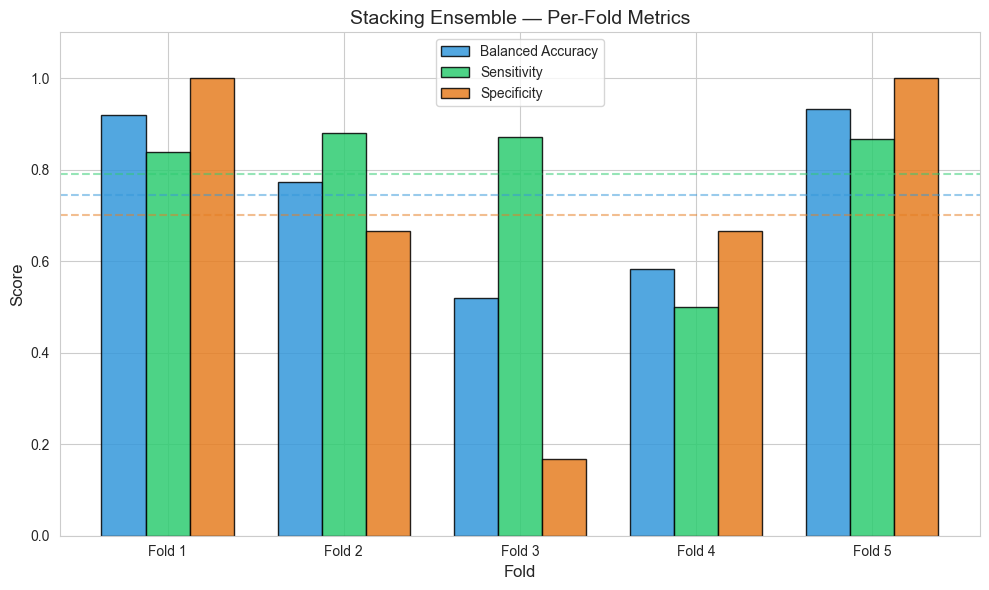

In [23]:
fold_df = pd.DataFrame(fold_results)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(fold_df))
width = 0.25

ax.bar(x - width, fold_df['balanced_accuracy'], width,
       label='Balanced Accuracy', color='#3498db',
       edgecolor='black', alpha=0.85)
ax.bar(x, fold_df['sensitivity'], width,
       label='Sensitivity', color='#2ecc71',
       edgecolor='black', alpha=0.85)
ax.bar(x + width, fold_df['specificity'], width,
       label='Specificity', color='#e67e22',
       edgecolor='black', alpha=0.85)

ax.set_xlabel('Fold')
ax.set_ylabel('Score')
ax.set_title('Stacking Ensemble — Per-Fold Metrics')
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i+1}' for i in range(len(fold_df))])
ax.legend()
ax.set_ylim(0, 1.1)

# Add mean lines
ax.axhline(y=fold_df['balanced_accuracy'].mean(), color='#3498db',
           linestyle='--', alpha=0.5)
ax.axhline(y=fold_df['sensitivity'].mean(), color='#2ecc71',
           linestyle='--', alpha=0.5)
ax.axhline(y=fold_df['specificity'].mean(), color='#e67e22',
           linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

---
## 7. Summary & Key Findings

### Methodology
- **Dataset**: UCI Oxford Parkinson's Disease Detection — 195 recordings, 31 subjects, 22 features
- **Validation**: Subject-wise GroupKFold (5-fold) at all levels to prevent data leakage
- **Feature Selection**: SVM-RFE outperformed PCA; selected features used for all models
- **Imbalance Handling**: `class_weight='balanced'` on all applicable learners (no SMOTE)

### Architecture
- **Base Learners**: SVM-RBF, KNN, Random Forest, Logistic Regression (L1) — all with tuned hyperparameters
- **Meta-Learner**: Logistic Regression L2 (C=0.1) trained on out-of-fold predicted probabilities
- **Meta-feature generation**: Inner 5-fold GroupKFold ensures no leakage between levels

### Key Findings
1. **Data leakage matters**: Record-wise CV dramatically inflates performance vs subject-wise CV
2. **SVM-RFE > PCA**: Supervised feature selection outperformed unsupervised dimensionality reduction on this dataset
3. **Multicollinearity**: Exact algebraic relationships (e.g., Jitter:DDP = 3 x MDVP:RAP) justify aggressive feature selection
4. **Honest performance**: With proper subject-wise validation, results fall in the 65-85% range — consistent with methodologically sound published work (Tougui et al., 2021)
5. **Stacking combines diverse learners**: The meta-learner learned to weight base learners according to their complementary strengths